In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os, tqdm, glob, scipy
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.49'

import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
from flax import nnx
import optax

import jaxpm
from jaxpm import hpm, camels, training, plotting, diagnostics, objectives
from jaxpm.painting import cic_paint, cic_read, compensate_cic
from jaxpm.splines import NeuralSplineFourierFilterNNX
from jaxpm.nn import MLP, ConditionedCNN
from jaxpm.objectives import ParticleLoss, FieldLoss

print(jax.default_backend())

/global/common/software/des/athomsen/flatiron/lib/python3.11/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


gpu


# configuration

In [22]:
parts_per_dim = 64
mesh_per_dim = parts_per_dim
mesh_shape = [mesh_per_dim] * 3

# references for the loss evaluation
i_snapshots = np.linspace(0, 33, 5, dtype=int)

# CAMELS

In [24]:
train_dict = camels.load_CV_snapshots(
    "CV_0",
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=i_snapshots,
    CAMELS="/pscratch/sd/a/athomsen/flatiron/CAMELS",
    CODE="SIMBA",
)

# vali_dict = camels.load_CV_snapshots(
#     "CV_1",
#     mesh_per_dim,
#     parts_per_dim,
#     i_snapshots=i_snapshots,
#     CAMELS="/pscratch/sd/a/athomsen/flatiron/CAMELS",
#     CODE="SIMBA",
# )

Loaded /pscratch/sd/a/athomsen/flatiron/CAMELS/h5/SIMBA/CV/CV_0/parts=64,mesh=64,i=[ 0  8 16 24 33].h5
Loaded /pscratch/sd/a/athomsen/flatiron/CAMELS/h5/SIMBA/CV/CV_1/parts=64,mesh=64,i=[ 0  8 16 24 33].h5


In [25]:
cosmo = train_dict["cosmo"]
solve_ode = training.get_ode_solver(mesh_per_dim, cosmo)
train_step = training.get_train_step(mesh_per_dim, cosmo)

# loss

### CAMELS ground truth

In [32]:
vcic_paint = jax.vmap(cic_paint, in_axes=(None,0,None))
vcic_read = jax.vmap(cic_read, in_axes=(0,0))

# general
cosmo = train_dict["cosmo"]
scales = train_dict["scales"]

# particles
dm_poss = train_dict["dm_poss"]
dm_vels = train_dict["dm_vels"]

gas_poss = train_dict["gas_poss"]
gas_vels = train_dict["gas_vels"]

# fields
dm_mass = cosmo.Omega_c / (cosmo.Omega_b + cosmo.Omega_c)
gas_mass = 1 - dm_mass

rhos_dm = vcic_paint(jnp.zeros(mesh_shape), dm_poss, dm_mass)
deltas_dm = rhos_dm/rhos_dm.mean() - 1

rhos_gas = vcic_paint(jnp.zeros(mesh_shape), gas_poss, gas_mass)
deltas_gas = rhos_gas/rhos_gas.mean() - 1

# power spectrum
_, cls_dm = objectives.vpower_spectrum(deltas_dm)
_, cls_gas = objectives.vpower_spectrum(deltas_gas)

# pressure correction

## model

In [37]:
pressure_model = ConditionedCNN(
    d_in=4,
    d_out=1,
    d_hidden=16,
    n_hidden=8,
    kernel_size=(3, 3, 3),
    rngs=nnx.Rngs(0),
    norm_type="layer",
    activation=jax.nn.swish,
    use_residual=True,
)

checkpoint_file = os.path.join(os.getcwd(), f"checkpoints/pressure_code={CODE},parts={parts_per_dim},mesh={mesh_per_dim}.jx")
# pressure_model.load(checkpoint_file)

## training

In [35]:
print(scales.shape)
print(gas_poss.shape)
print(gas_vels.shape)
print(cls_gas.shape)
print(deltas_gas.shape)

(5,)
(5, 262144, 3)
(5, 262144, 3)
(5, 31)
(5, 64, 64, 64)


In [47]:
def train_step_wrapper(i0=0, i_ref=None, aug_key=None):
    y0 = (dm_poss[i0], dm_vels[i0], gas_poss[i0], gas_vels[i0])
    t0 = scales[i0]

    if all_steps := (i_ref is None):
        i_ref = np.arange(i0, len(scales))

    loss, grad = train_step(
        pressure_loss_fn,
        pressure_optimizer,
        y0,
        t0,
        ref_t=scales[i_ref],
        ref_poss=gas_poss[i_ref],
        ref_vels=gas_vels[i_ref],
        ref_cls=cls_gas[i_ref],
        ref_deltas=deltas_gas[i_ref],
        pressure_model=pressure_model,
        gravity_model=None,
        model_to_train="pressure",
        aug_key=aug_key,
        tstep=scales[(t0 <= scales) & (scales <= scales[i_ref[-1]])],
        nt=10,
    )

    losses.append(float(loss))
    grads.append(float(grad))
    pbar.set_description(f"[{i_ref[0]}, {i_ref[-1]}], Loss: {loss:.4e}, Grad: {grad:.4e}")


def plot_training(losses, grad_norms):
    fig, ax = plt.subplots(figsize=(6, 10), nrows=2, sharex=True)
    ax[0].plot(losses)
    ax[0].set(yscale="log", title="loss")

    ax[1].plot(grad_norms)
    ax[1].set(yscale="log", title="norm(grad)")


### loss

In [48]:
pressure_loss_fn = ParticleLoss(
    mesh_per_dim,
    w_pos=1.0,
    w_vel=0.01,
    w_cls=0.1,
    w_cross=0.0,
    w_snapshot=0.0,
    k_max=2,
    loss_type="huber",
    robust_scale=mesh_per_dim//16,
    cutoff_quantile=0.95,
)

### optimizer

In [49]:
total_steps = 100

learning_rate = 1e-4
clip_norm = 1
pressure_optimizer = nnx.ModelAndOptimizer(
    pressure_model,
    optax.chain(
        optax.clip_by_global_norm(clip_norm),
        optax.adam(learning_rate)
    )
)

losses = []
grads = []

pressure_losses = []
gravity_losses = []

## training

In [50]:
key = jax.random.key(71)

# all selected snapshots except the initial conditions
i_ref = jnp.arange(1, len(i_snapshots))

for i in (pbar := tqdm.tqdm(range(total_steps))):
    key, subkey = jax.random.split(key)
    train_step_wrapper(i0=i0, i_ref=i_ref, aug_key=subkey)

plot_training(losses, grads)

  0%|          | 0/300 [00:00<?, ?it/s]

Applying augmentations (random flips and 90 degree rotations)
Solving ODE in 45 steps (StepTo with 10 steps between ts)
dark matter and gas
Using learned pressure force
No latent variable
dark matter and gas
Using learned pressure force
No latent variable
dark matter and gas
Using learned pressure force
No latent variable
Using particle loss
w_pos = 1.0, loss = huber, scale = 4.0
w_vel = 0.01, loss = huber, scale = 16.0
w_cls = 0.1, k_max = 2, k_type = step


[1, 4], Loss: 1.3814e+00, Grad: 1.5638e+01:  39%|███▉      | 118/300 [02:13<03:25,  1.13s/it]


KeyboardInterrupt: 

### checkpointing

In [ ]:
pressure_model.save(checkpoint_file)

# testing

Solving ODE in 45 steps (StepTo with 10 steps between ts)
dark matter and gas
dark matter and gas
dark matter and gas
Solving ODE in 45 steps (StepTo with 10 steps between ts)
dark matter and gas
Using learned pressure force
No latent variable
dark matter and gas
Using learned pressure force
No latent variable
dark matter and gas
Using learned pressure force
No latent variable


100%|██████████| 5/5 [00:12<00:00,  2.59s/it]


Solving ODE in 45 steps (StepTo with 10 steps between ts)
dark matter and gas
dark matter and gas
dark matter and gas
Solving ODE in 45 steps (StepTo with 10 steps between ts)
dark matter and gas
Using learned pressure force
No latent variable
dark matter and gas
Using learned pressure force
No latent variable
dark matter and gas
Using learned pressure force
No latent variable


100%|██████████| 5/5 [00:12<00:00,  2.58s/it]


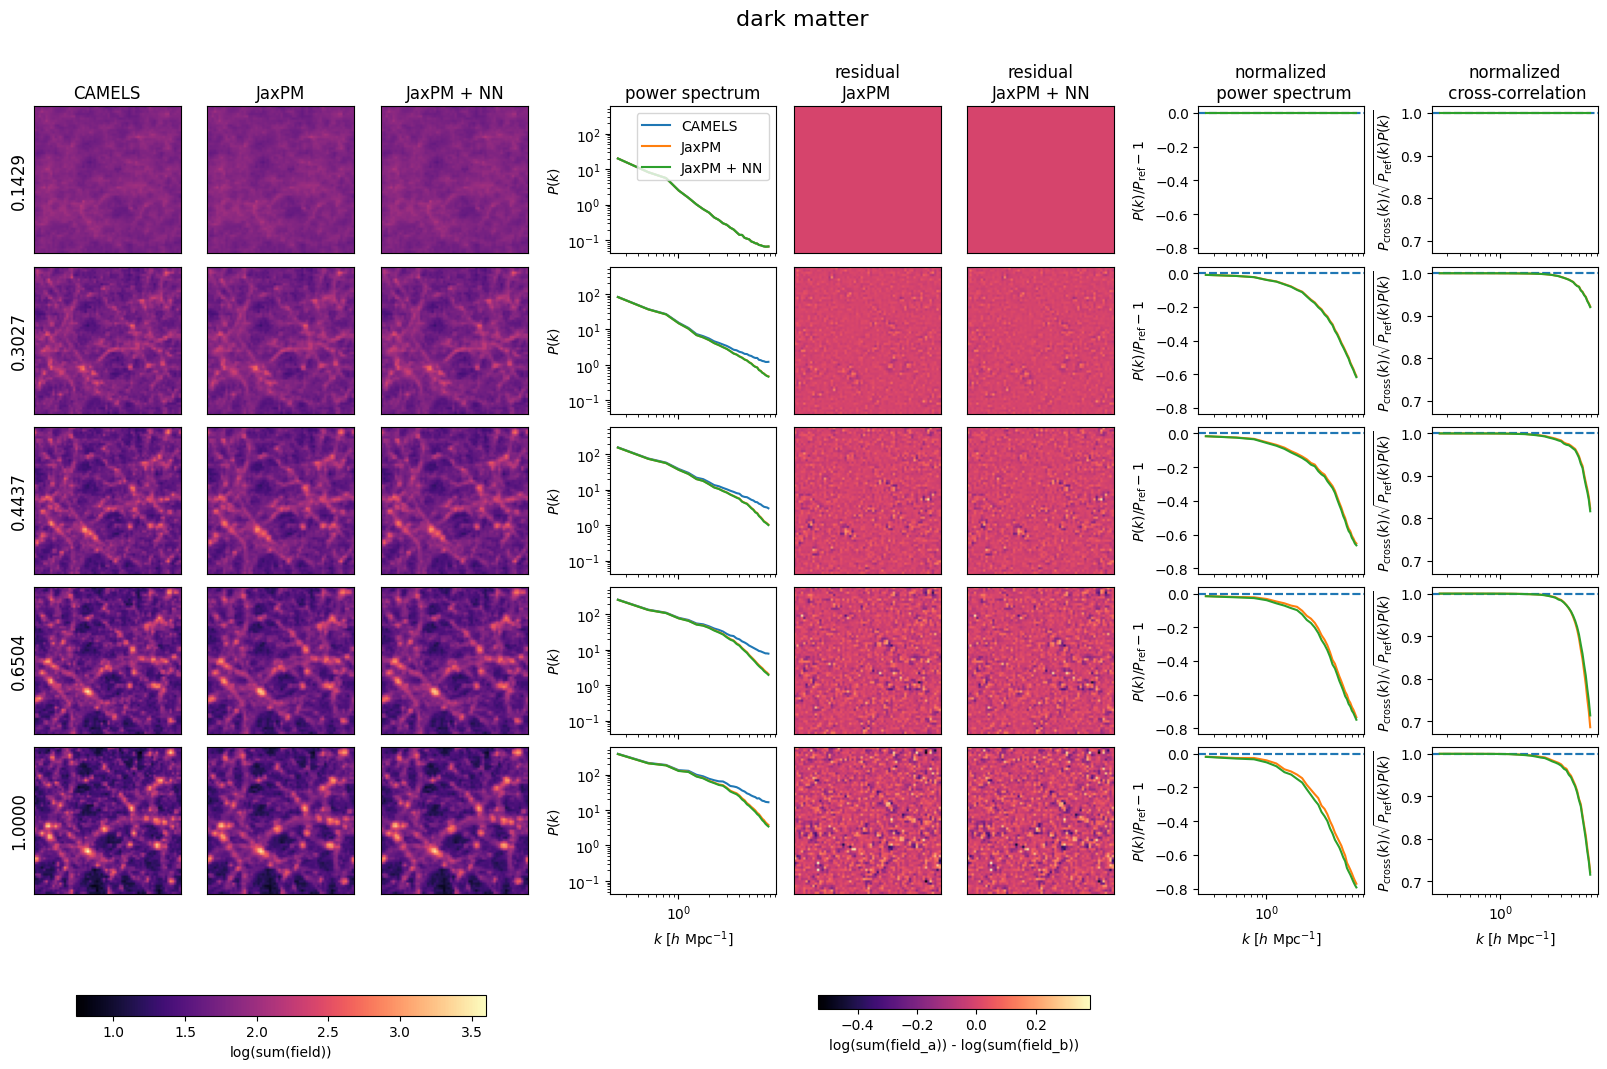

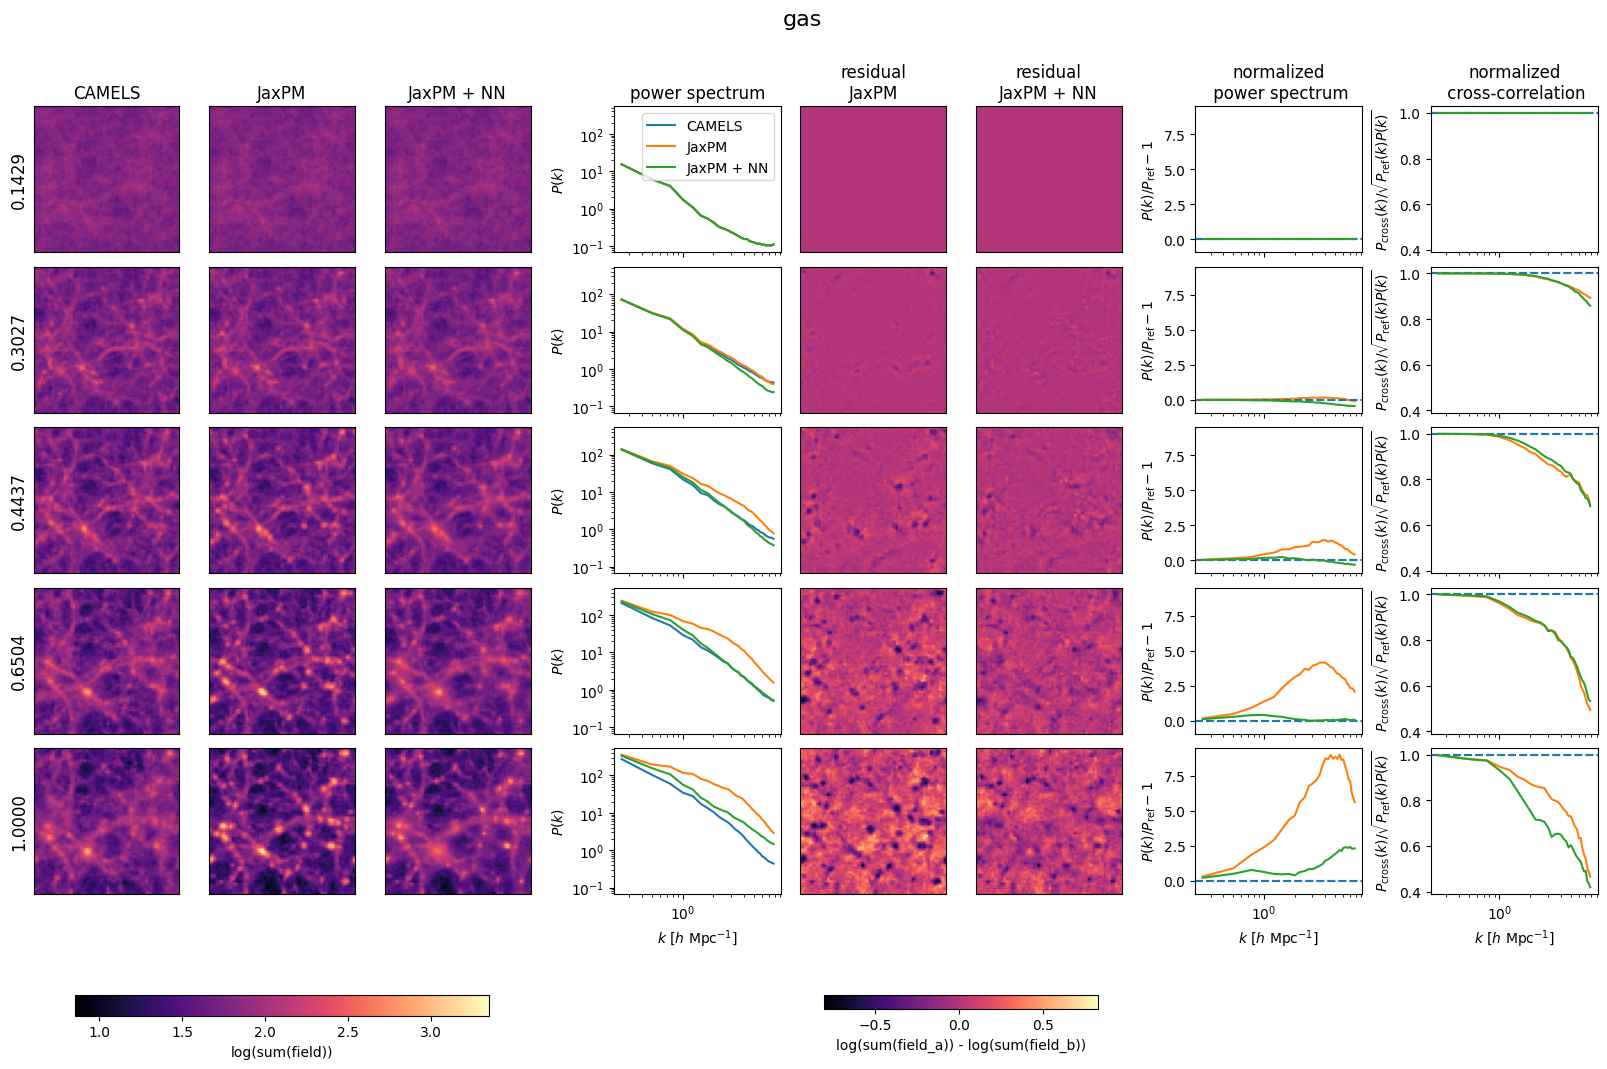

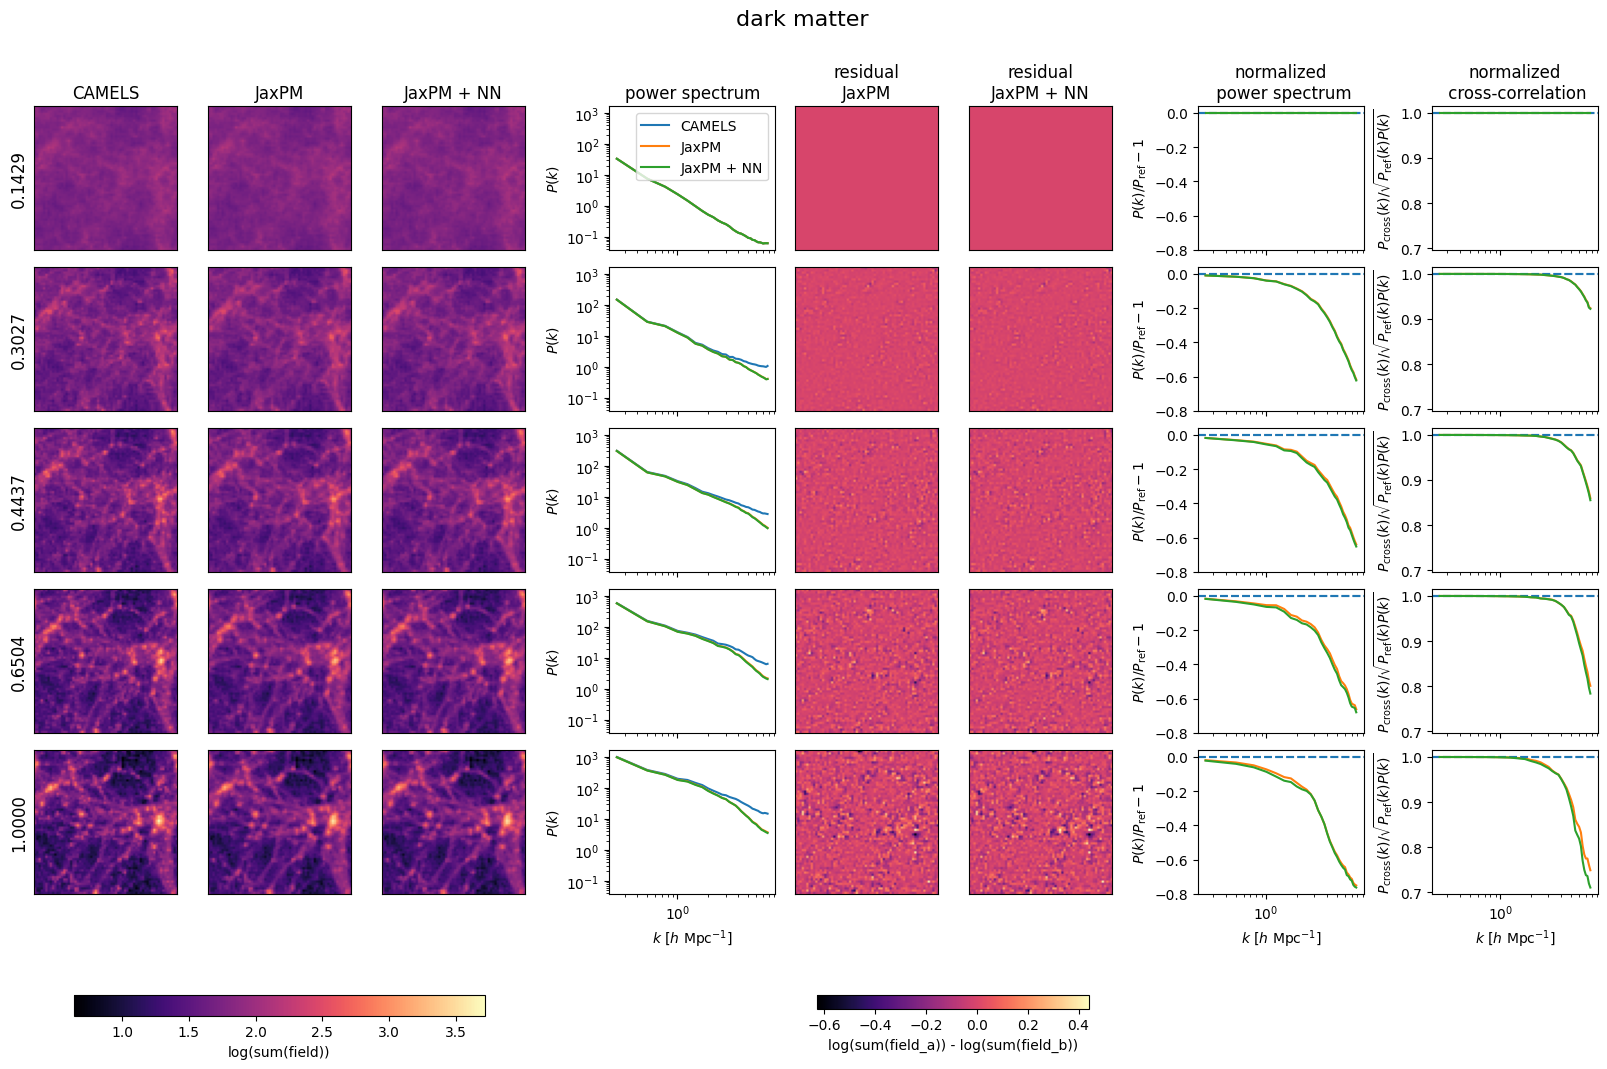

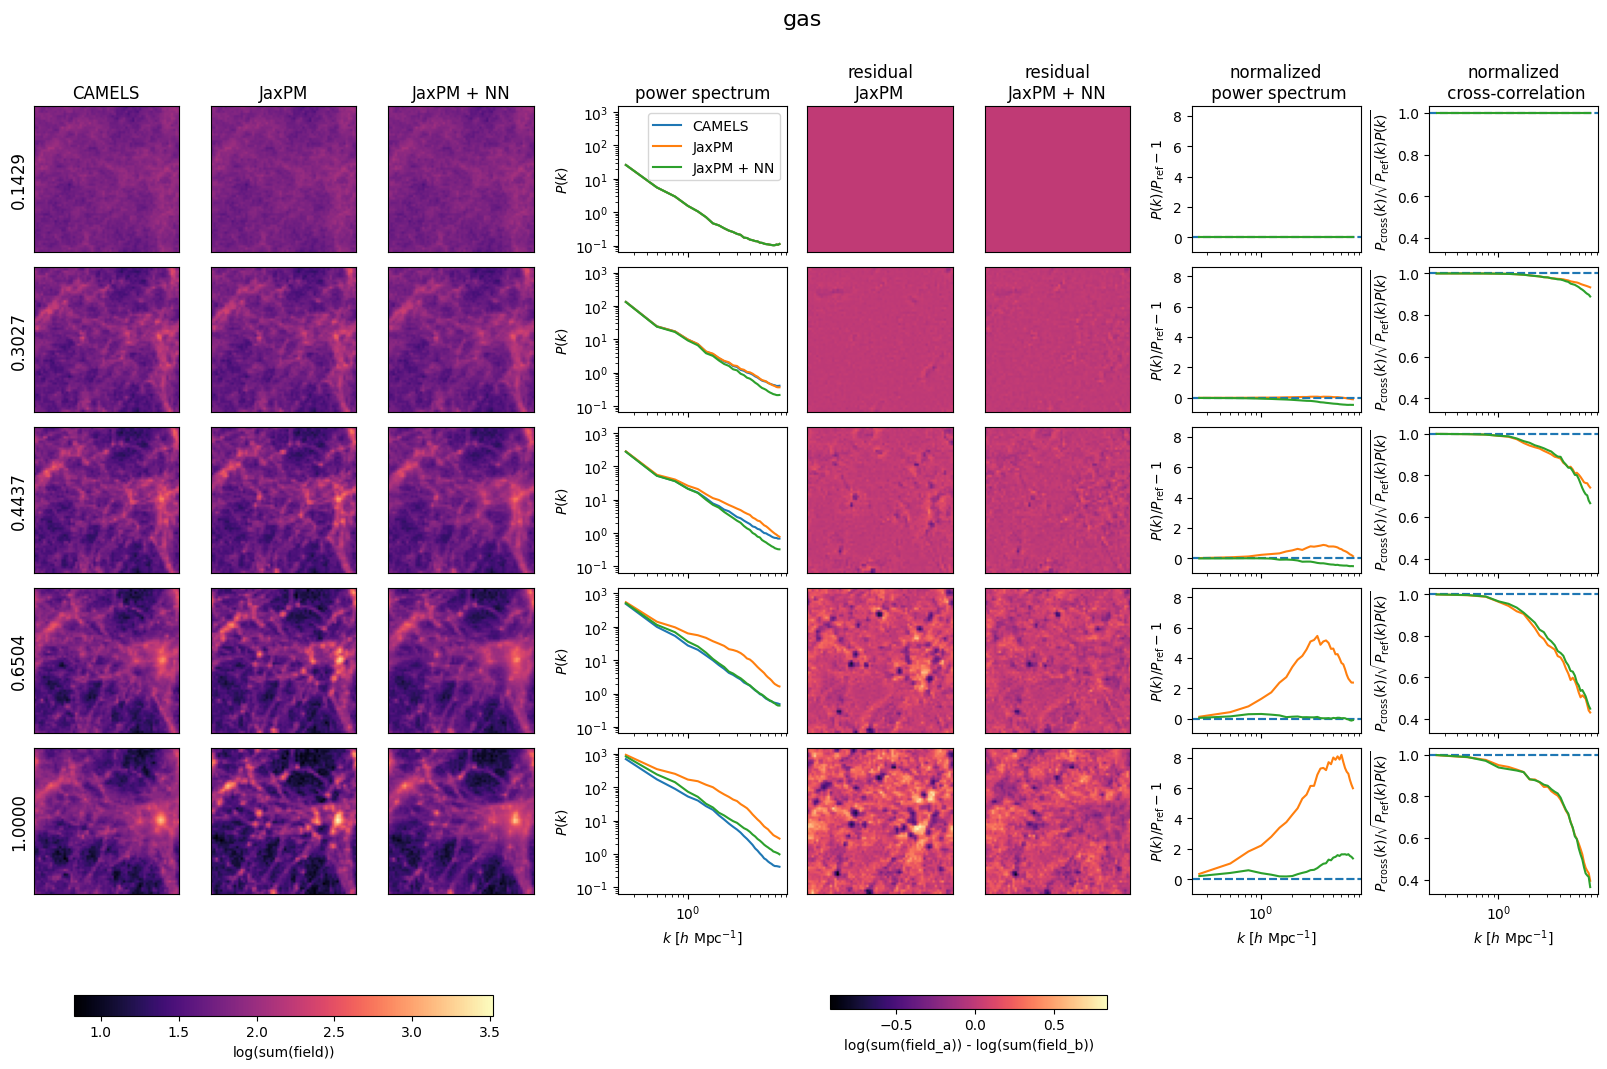

In [52]:
for camels_dict in [train_dict, vali_dict]:
    diagnostics.run_simulations(
        camels_dict,
        mesh_per_dim,
        pressure_model=pressure_model, 
        nt=10,
        plot_dm=False,
        plot_gas=True,
    )